<a href="https://colab.research.google.com/github/kjfcvx12/Colab/blob/main/04_21_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
import torch
import torchvision
from torchvision import datasets
import numpy as np

from PIL import Image
import matplotlib.pyplot as plt
from torchvision import transforms

In [23]:
# 운영체제 관련기능
import os
# 파일이나 폴더 복사, 이동, 삭제
import shutil
torch.manual_seed(0)

In [24]:
!pip install gdown

In [25]:
!gdown 1ql4oc0aAKL3Aw7q-6XwfD_ZaK9bPh9Wl -O covid.zip

Failed to retrieve file url:

	Too many users have viewed or downloaded this file recently. Please
	try accessing the file again later. If the file you are trying to
	access is particularly large or is shared with many people, it may
	take up to 24 hours to be able to view or download the file. If you
	still can't access a file after 24 hours, contact your domain
	administrator.

You may still be able to access the file from the browser:

	https://drive.google.com/uc?id=1ql4oc0aAKL3Aw7q-6XwfD_ZaK9bPh9Wl

but Gdown can't. Please check connections and permissions.


In [26]:
# 현재폴더에 압축해제
!unzip -q covid.zip -d /content/

replace /content/COVID-19 Radiography Database/test/covid/COVID-19 (1).png? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [55]:
# 압축해제 후 전체 데이터셋 폴더명을 변수에 저장함
# /content/COVID-19/train
data_dir='COVID-19 Radiography Database'
train_dir=os.path.join(data_dir,'train')
val_dir=os.path.join(data_dir,'test')

print(os.listdir(data_dir))
print(os.listdir(train_dir))
print(os.listdir(val_dir))

['train', 'test']
['covid', 'normal', 'viral']
['covid', 'normal', 'viral']


In [56]:
from torchvision.transforms import Compose, Resize, RandomHorizontalFlip, ToTensor,Normalize

In [57]:
# 데이터 증강(Data Augmentation)
# 기존 이미지를 뒤집기, 좌우뒤집기 => 새로운 사진 들어오는 것과 비슷한 효과

In [58]:
train_transform=Compose([
    Resize(size=(224,224)),
    # 이미지를 랜덤으로 수평으로(좌우) 뒤집기 (데이터 증강) => 양 늘리기, 편향제거(과적합방지)
    RandomHorizontalFlip(),
    # 이미지를 텐서로 변환(0~1 정규화)
    ToTensor(),
    # ImageNet (120만장) -> RGB채 채널 평균값/표준편차
    Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225))
])

test_transform=Compose([
    Resize(size=(224,224)),
    # 이미지를 랜덤으로 수평으로(좌우) 뒤집기 (데이터 증강) => 양 늘리기, 편향제거(과적합방지)
    ToTensor(),
    # ImageNet (120만장) -> RGB채 채널 평균값/표준편차
    Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225))
])

In [59]:
# ImageFolder : 파이토치에서 데이터 관리하는 표준 방법
# train/covid 0번, train/normal 1번 -> 코로나, 정상, ... 알릴 필요없이 폴더에 넣기만 하면 파이토치가 알아서 이름표(레이블링)
train_data=datasets.ImageFolder(os.path.join(data_dir, 'train'), train_transform)
test_data=datasets.ImageFolder(os.path.join(data_dir, 'test'), test_transform)

In [60]:
print(train_data.classes)
print(train_data.class_to_idx)
print(len(train_data))

['covid', 'normal', 'viral']
{'covid': 0, 'normal': 1, 'viral': 2}
2816


In [61]:
train_loader=torch.utils.data.DataLoader(train_data, batch_size=6, shuffle=True)
test_loader=torch.utils.data.DataLoader(test_data, batch_size=6, shuffle=False)

In [62]:
print(len(train_loader))
print(len(test_loader))

470
15


In [63]:
classnames=train_data.classes
print(classnames)

['covid', 'normal', 'viral']


In [64]:
# 이미지 출력
def show(images, labels, pred):
  plt.figure(figsize=(8,3))

  for i, image in enumerate(images):
    plt.subplot(1,6,i+1, xticks=[], yticks=[])
    # 텐서형태 변환
    # 파이토치 이미지 (채널, 높이, 너비) => matplotlib(높이, 너비, 채널)
    image=image.numpy().transpose((1,2,0))
    mean=np.array([0.485,0.456,0.406])
    std=np.array([0.229,0.224,0.225])
    # 역정규화(원래 색감으로 되돌린다)
    image=image*std+mean
    # 색상 유지(0보다 작거나 1보다 커진값은 강제로 잘라낸다)
    image=np.clip(image,0.,1.)

    plt.imshow(image)

    color1='green'
    if pred[i] != labels[i]:
      color11='red'

    plt.xlabel(classnames[int(labels[i].numpy())])
    plt.ylabel(classnames[int(pred[i].numpy())], color=color1)


  plt.tight_layout()
  plt.show()

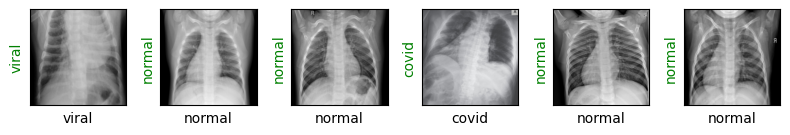

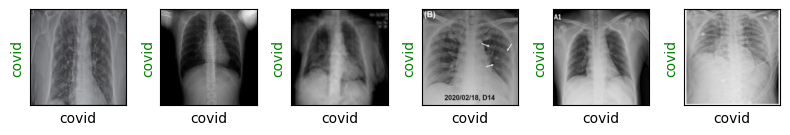

In [65]:
images, labels=next(iter(train_loader))
show(images, labels, labels)

images, labels=next(iter(test_loader))
show(images, labels, labels)

In [66]:
# 이미 ex)1000가지 이미지를 구분할 줄 아는 가중치를 내려 받음
resnet=torchvision.models.resnet18(pretrained=True)
resnet

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [67]:
device="cuda:0" if torch.cuda.is_available() else "cpu"
device

'cuda:0'

In [68]:
resnet.fc=torch.nn.Linear(in_features=512, out_features=3)

# 모델 gpu로 옮김
resnet.to(device)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [69]:
# 다중분류 손실함수
crossloss=torch.nn.CrossEntropyLoss()
optimizer=torch.optim.Adam(resnet.parameters(), lr=0.001)

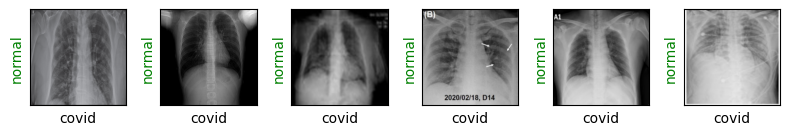

In [70]:
def pred():
  # 모델을 평가모드로 설정
  resnet.eval()
  images, labels=next(iter(test_loader))
  images=images.to(device)

  #[0.1,0.6,0.3]
  outputs=resnet(images)
  #dim=1 (행마다 가로 훑어서 가장 큰값)
  _,preds=torch.max(outputs, 1)

  show(images.cpu(), labels, preds.cpu())

pred()

In [ ]:
#model학습(과제 2) - loss와 accuracy 출력 (epoch 20번)